# LSTM-scénario opérationnel


In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path("..") / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
import json

from models.lstm.features_lstm import (
    charger_dataset, construire_jeu, decouper, desnormaliser,
    SL_J7, SL_J1, PROCESSED_DIR,
)
from models.lstm.entrainer_lstm import (
    entrainer_lstm, entrainer_ensemble, evaluer, predire,
)


## 1. Séquences

In [2]:
df = charger_dataset()
X_seq, X_stat, y, dates, scalers = construire_jeu(df)
print("X_seq", X_seq.shape, "| X_stat", X_stat.shape, "| y", y.shape)   # (N,168,10) (N,67) (N,24)
jeux = decouper(X_seq, X_stat, y, dates)
print({k: len(v[0]) for k, v in jeux.items()})

X_seq (3886, 168, 10) | X_stat (3886, 67) | y (3886, 24)
{'train': 2891, 'val': 363, 'test': 632}


## 2. Choix de l'architecture sur la validation
Trois variantes (une graine chacune) ; on garde la meilleure MAE **validation**.

In [3]:
VARIANTES = {
    "simple (h=64)":            dict(hidden=64,  dropout=0.2, residu=False),
    "résiduelle (h=64)":        dict(hidden=64,  dropout=0.2, residu=True),
    "plus large (h=128, d=0.3)": dict(hidden=128, dropout=0.3, residu=False),
}
res = {}
for nom, cfg in VARIANTES.items():
    print(f"--- {nom}")
    m, h = entrainer_lstm(jeux["train"], jeux["val"], verbose=False, **cfg)
    res[nom] = evaluer(m, jeux["val"], scalers)[0]
    print({k: round(v, 2) for k, v in res[nom].items()}, "| epochs :", len(h["val"]))

tab = pd.DataFrame(res).T.round(2)
display(tab)
MEILLEURE = tab["mae"].idxmin()
CONFIG = VARIANTES[MEILLEURE]
print("Variante retenue (validation) :", MEILLEURE, CONFIG)

--- simple (h=64)
{'mae': 1116.12, 'rmse': 1610.17, 'mape': 2.15} | epochs : 48
--- résiduelle (h=64)
{'mae': 1103.5, 'rmse': 1623.32, 'mape': 2.13} | epochs : 56
--- plus large (h=128, d=0.3)
{'mae': 1181.64, 'rmse': 1667.08, 'mape': 2.29} | epochs : 39


,mae,rmse,mape
simple (h=64),1116.12,1610.17,2.15
résiduelle (h=64),1103.50,1623.32,2.13
"plus large (h=128, d=0.3)",1181.64,1667.08,2.29


Variante retenue (validation) : résiduelle (h=64) {'hidden': 64, 'dropout': 0.2, 'residu': True}


## 3. Modèle final : ensemble de 5 réseaux 

In [4]:
modeles = entrainer_ensemble(jeux["train"], jeux["val"], n_modeles=5, **CONFIG)

m_tr = evaluer(modeles, jeux["train"], scalers)[0]
m_va = evaluer(modeles, jeux["val"], scalers)[0]
print("Train      :", {k: round(v, 2) for k, v in m_tr.items()})
print("Validation :", {k: round(v, 2) for k, v in m_va.items()}, "| XGBoost v2 val : 1227.4")

modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Train      : {'mae': 950.61, 'rmse': 1390.98, 'mape': 1.74}
Validation : {'mae': 1088.95, 'rmse': 1605.4, 'mape': 2.09} | XGBoost v2 val : 1227.4


In [5]:
import matplotlib.dates as mdates

res3 = {}
for nom in ["train", "val"]:
    _, pred, reel = evaluer(modeles, jeux[nom], scalers)
    res3[nom] = (pred, reel, jeux[nom][3])

mae_tr = np.abs(res3["train"][0] - res3["train"][1]).mean()
mae_va = np.abs(res3["val"][0] - res3["val"][1]).mean()
print(f"MAE train {mae_tr:.0f} | MAE validation {mae_va:.0f} | écart {mae_va - mae_tr:.0f} MW "
      f"({100 * (mae_va / mae_tr - 1):.0f} %)")

MAE train 951 | MAE validation 1089 | écart 138 MW (15 %)


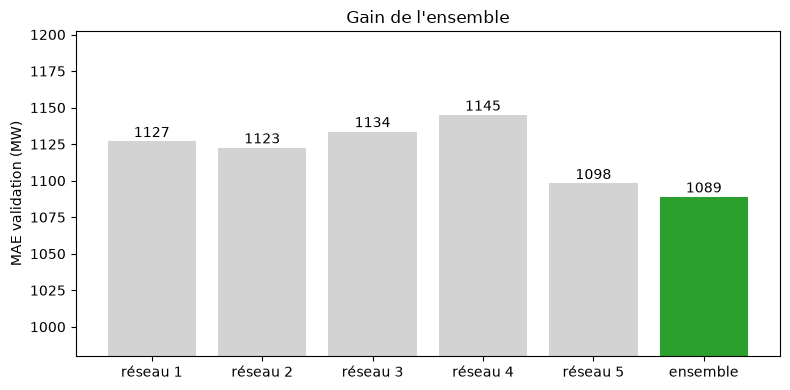

In [8]:
#les 5 réseaux seuls contre l'ensemble (validation)
maes_ind = [evaluer(m, jeux["val"], scalers)[0]["mae"] for m in modeles]
etiquettes = [f"réseau {i + 1}" for i in range(len(modeles))] + ["ensemble"]
valeurs = maes_ind + [mae_va]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(etiquettes, valeurs, color=["lightgray"] * len(modeles) + ["tab:green"])
for i, v in enumerate(valeurs):
    ax.text(i, v + 3, f"{v:.0f}", ha="center")
ax.set_ylim(min(valeurs) * 0.9, max(valeurs) * 1.05)
ax.set_ylabel("MAE validation (MW)"); ax.set_title("Gain de l'ensemble")
plt.tight_layout(); plt.show()

## 4. Test et baselines

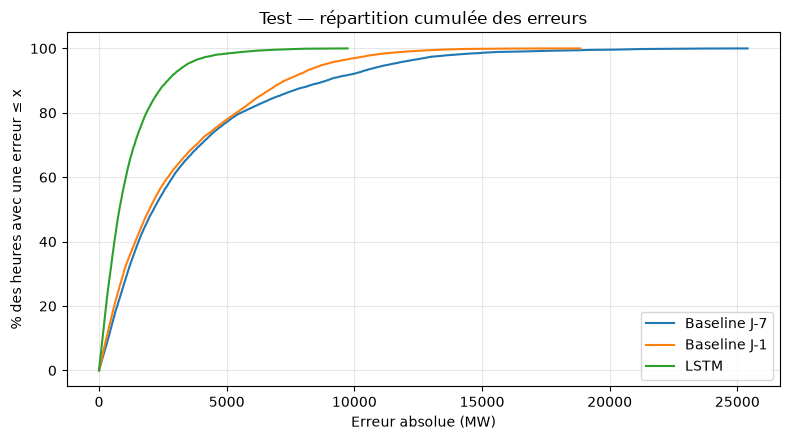

In [11]:
#distribution des erreurs (la queue montre les jours difficiles)
err_abs = {
    "Baseline J-7": np.abs(j7 - reel_te).ravel(),
    "Baseline J-1": np.abs(j1 - reel_te).ravel(),
    "LSTM":         np.abs(pred_te - reel_te).ravel(),
}
fig, ax = plt.subplots(figsize=(8, 4.5))
for nom, e in err_abs.items():
    x = np.sort(e)
    ax.plot(x, np.arange(1, len(x) + 1) / len(x) * 100, label=nom)
ax.set_xlabel("Erreur absolue (MW)"); ax.set_ylabel("% des heures avec une erreur ≤ x")
ax.set_title("Test — répartition cumulée des erreurs"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

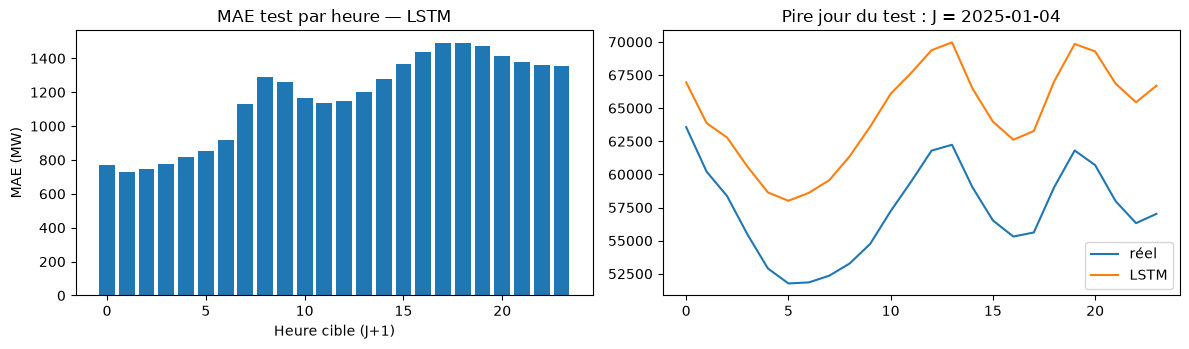

In [13]:
mae_h = np.abs(pred_te - reel_te).mean(axis=0)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(range(24), mae_h); ax[0].set_xlabel("Heure cible (J+1)"); ax[0].set_ylabel("MAE (MW)")
ax[0].set_title("MAE test par heure — LSTM")

i = int(np.argmax(np.abs(pred_te - reel_te).mean(axis=1)))          # pire jour
ax[1].plot(reel_te[i], label="réel"); ax[1].plot(pred_te[i], label="LSTM")
ax[1].set_title(f"Pire jour du test : J = {jeux['test'][3][i].date()}"); ax[1].legend()
plt.tight_layout(); plt.show()

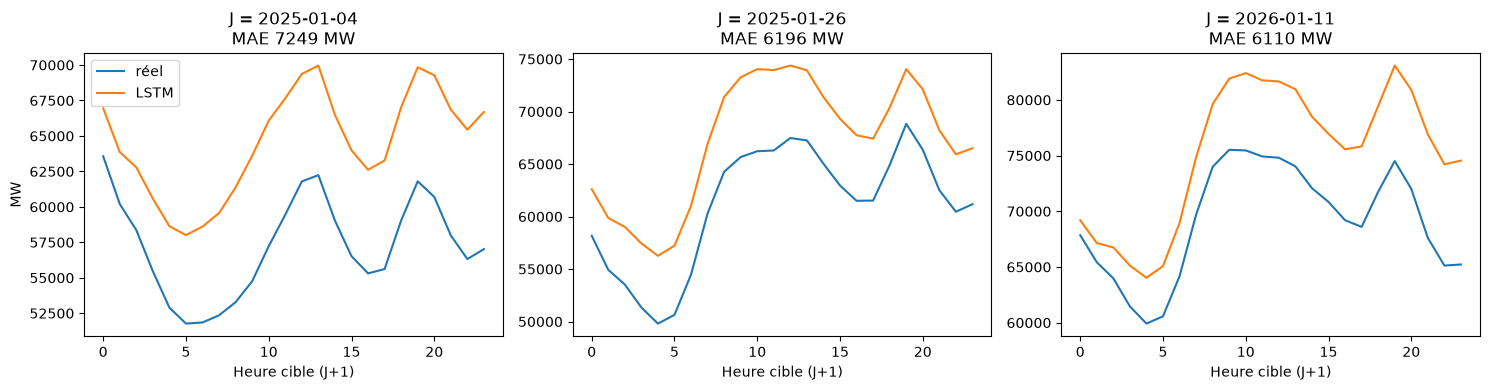

In [15]:
#les 3 pires jours du test (réel contre prévu)
mae_jour = np.abs(pred_te - reel_te).mean(axis=1)
pires = np.argsort(mae_jour)[::-1][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, k in zip(axes, pires):
    ax.plot(reel_te[k], label="réel"); ax.plot(pred_te[k], label="LSTM")
    ax.set_title(f"J = {jeux['test'][3][k].date()}\nMAE {mae_jour[k]:.0f} MW")
    ax.set_xlabel("Heure cible (J+1)")
axes[0].set_ylabel("MW"); axes[0].legend()
plt.tight_layout(); plt.show()

## 5. Analyse des échecs : les 10 pires jours de XGBoost v2 avec le LSTM

C:\Users\bahri\AppData\Local\Temp\ipykernel_11300\4093371718.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  J1 = J + pd.Timedelta(days=1)
C:\Users\bahri\AppData\Local\Temp\ipykernel_11300\4093371718.py:12: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  h14 = J + pd.Timedelta(hours=14)
C:\Users\bahri\AppData\Local\Temp\ipykernel_11300\4093371718.py:15: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  t_24h = temp.loc[h14 - pd.Timedelta(hours=23):h14].mean()      # moyenne des 24 h précéd

,jour_cible,férié,vacances,T 14h (°C),T moy 24h (°C),T réelle J+1 (°C),écart T (°C),MAE (MW),biais (MW),accuracy %
jour_J,,,,,,,,,,
2025-01-04,Sunday,0,3,4.0,1.6,10.1,8.5,7249,-7249,87.290001
2025-01-26,Monday,0,0,8.1,7.1,10.5,3.4,6196,-6196,89.790001
2026-01-11,Monday,0,0,4.5,2.6,7.6,5.0,6110,-6110,91.220001
2026-01-02,Saturday,0,3,3.5,1.4,0.1,-1.3,4773,4773,93.239998


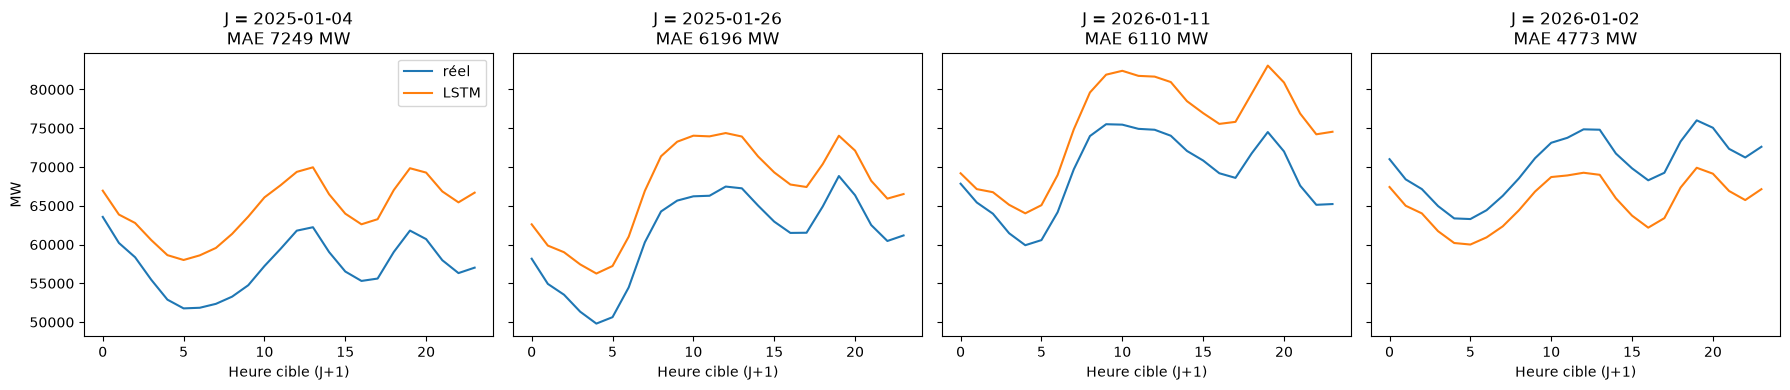

In [16]:
JOURS = ["2025-01-04", "2025-01-26", "2026-01-11", "2026-01-02"]

d = df.set_index("timestamp_paris")
temp = d["temperature_c_pondere_pop"]
dates_test = jeux["test"][3]
lignes = []

for j in JOURS:
    J = pd.Timestamp(j, tz="Europe/Paris")
    J1 = J + pd.Timedelta(days=1)
    k = int(np.where(dates_test == J)[0][0])
    h14 = J + pd.Timedelta(hours=14)

    t_14h = temp.loc[h14]                                          # dernière valeur connue
    t_24h = temp.loc[h14 - pd.Timedelta(hours=23):h14].mean()      # moyenne des 24 h précédentes
    t_j1 = temp.loc[J1:J1 + pd.Timedelta(hours=23)].mean()         # réalité de J+1 (inconnue à 14h)

    erreur = np.abs(pred_te[k] - reel_te[k]).mean()
    lignes.append({
        "jour_J": j, "jour_cible": J1.day_name(),
        "férié": int(d.loc[J1 + pd.Timedelta(hours=12), "ferie"]),
        "vacances": int(d.loc[J1 + pd.Timedelta(hours=12), "vacances"]),
        "T 14h (°C)": round(t_14h, 1), "T moy 24h (°C)": round(t_24h, 1),
        "T réelle J+1 (°C)": round(t_j1, 1), "écart T (°C)": round(t_j1 - t_24h, 1),
        "MAE (MW)": round(erreur), "biais (MW)": round((reel_te[k] - pred_te[k]).mean()),
        "accuracy %": round(100 - (np.abs(pred_te[k] - reel_te[k]) / reel_te[k]).mean() * 100, 2),
    })
tab_echecs = pd.DataFrame(lignes).set_index("jour_J")
display(tab_echecs)

fig, axes = plt.subplots(1, len(JOURS), figsize=(4.5 * len(JOURS), 4), sharey=True)
for ax, j in zip(axes, JOURS):
    k = int(np.where(dates_test == pd.Timestamp(j, tz="Europe/Paris"))[0][0])
    ax.plot(reel_te[k], label="réel"); ax.plot(pred_te[k], label="LSTM")
    ax.set_title(f"J = {j}\nMAE {np.abs(pred_te[k] - reel_te[k]).mean():.0f} MW")
    ax.set_xlabel("Heure cible (J+1)")
axes[0].set_ylabel("MW"); axes[0].legend()
plt.tight_layout(); plt.show()


Dans les quatre cas, la **forme** de la courbe journalière est correcte (creux nocturne, pointes du matin et du soir), mais toute la courbe est **décalée** d'un niveau à peu près constant sur les 24 heures. L'erreur porte donc sur le niveau global de la consommation, et non sur sa dynamique horaire.


**Trois jours de surestimation (04/01/2025, 26/01/2025, 11/01/2026) : un redoux non anticipé.**
La température connue à 14 h le jour J (moyenne des 24 h précédentes : 1,6 °C, 7,1 °C et 2,6 °C) est inférieure de 3,4 à 8,5 °C à la température réellement observée le lendemain (10,1 °C, 10,5 °C et 7,6 °C). Le modèle ne dispose que d'observations passées : il prévoit un besoin de chauffage proche de celui de la veille, alors que le temps s'est adouci. La consommation réelle est plus basse que prévu toute la journée (−6 100 à −7 250 MW). L'effet est maximal le 05/01/2025, qui cumule le plus fort redoux (+8,5 °C) et un dimanche en période de vacances scolaires.

**Un jour de sous-estimation (02/01/2026) : un effet de calendrier, pas de météo.**
La température varie peu (−1,3 °C), pourtant le modèle sous-estime de 4 773 MW. La prévision moyenne (65 426 MW) reste proche du niveau de la même journée de la semaine précédente (samedi 27/12/2025 : 64 343 MW, en pleine période de Noël), alors que la consommation réelle remonte à 70 200 MW (+9,1 %) avec la reprise d'activité de début janvier et un temps plus froid. Le modèle s'appuie donc sur une semaine de référence atypique. Cette explication est cohérente avec les chiffres, mais ne l'établit pas à elle seule (la température du 27/12 n'est pas connue ici).

### L'information était-elle disponible à 14 h ?

- **Météo de J+1 : non.** Les données SYNOP sont des observations : à 14 h le jour J, la température du lendemain n'est pas connue. Ces trois erreurs ne sont pas des fautes de modélisation mais la conséquence d'une information manquante par construction du protocole.
- **Calendrier : oui.** La position dans les vacances de fin d'année est connue à l'avance, mais le modèle n'a pas de variable qui la décrive finement.


## Ablation

In [26]:
from models.lstm.features_lstm import NOMS_SEQ, SL_CAL, SL_MET, SL_J7, SL_J1


idx = {nom: i for i, nom in enumerate(NOMS_SEQ)}
GROUPES = {
    "météo":         dict(seq=[idx[c] for c in NOMS_SEQ[1:6]],
                          stat=[SL_MET]),
    "calendrier":    dict(seq=[idx[c] for c in ["heure_sin", "heure_cos", "weekend", "ferie"]],
                          stat=[SL_CAL]),
    "retards conso": dict(seq=[idx["consommation_mw"]],
                          stat=[SL_J7, SL_J1]),
}

def masquer(jeu, groupe):
    """Copie du jeu avec le groupe de variables mis à zéro (None = jeu complet)."""
    Xs, Xt, y, d = jeu
    Xs, Xt = Xs.copy(), Xt.copy()
    if groupe is not None:
        g = GROUPES[groupe]
        Xs[:, :, g["seq"]] = 0
        for sl in g["stat"]:
            Xt[:, sl] = 0
    return (Xs, Xt, y, d)

In [27]:
N_ABL = 3                                   # réseaux par configuration (3 suffisent, plus rapide que 5)
cfg = dict(CONFIG, residu=False)            # pas de base J-6 : sinon « sans retards » ne serait pas propre

lignes = []
for nom, grp in [("Modèle complet", None), ("Sans météo", "météo"),
                 ("Sans calendrier", "calendrier"), ("Sans retards conso", "retards conso")]:
    print(f"\n=== {nom} ===")
    tr_, va_, te_ = (masquer(jeux[k], grp) for k in ("train", "val", "test"))
    ms = entrainer_ensemble(tr_, va_, n_modeles=N_ABL, **cfg)
    lignes.append({
        "configuration": nom,
        "MAE val": evaluer(ms, va_, scalers)[0]["mae"],
        "MAE test": evaluer(ms, te_, scalers)[0]["mae"],
    })

abl = pd.DataFrame(lignes).set_index("configuration")
abl["Δ MAE test vs complet"] = abl["MAE test"] - abl.loc["Modèle complet", "MAE test"]
abl["Δ %"] = 100 * abl["Δ MAE test vs complet"] / abl.loc["Modèle complet", "MAE test"]
display(abl.round(1))
print("Rappel : ensemble final de 5 réseaux -> MAE val",
      round(evaluer(modeles, jeux["val"], scalers)[0]["mae"], 1), "| MAE test",
      round(evaluer(modeles, jeux["test"], scalers)[0]["mae"], 1))


=== Modèle complet ===
modèle 1/3 entraîné
modèle 2/3 entraîné
modèle 3/3 entraîné

=== Sans météo ===
modèle 1/3 entraîné
modèle 2/3 entraîné
modèle 3/3 entraîné

=== Sans calendrier ===
modèle 1/3 entraîné
modèle 2/3 entraîné
modèle 3/3 entraîné

=== Sans retards conso ===
modèle 1/3 entraîné
modèle 2/3 entraîné
modèle 3/3 entraîné


,MAE val,MAE test,Δ MAE test vs complet,Δ %
configuration,,,,
Modèle complet,1107.3,1217.1,0.0,0.0
Sans météo,1295.9,1395.8,178.7,14.7
Sans calendrier,1353.3,1430.7,213.6,17.5
Sans retards conso,2311.0,2019.8,802.7,65.9


Rappel : ensemble final de 5 réseaux -> MAE val 1088.9 | MAE test 1166.1


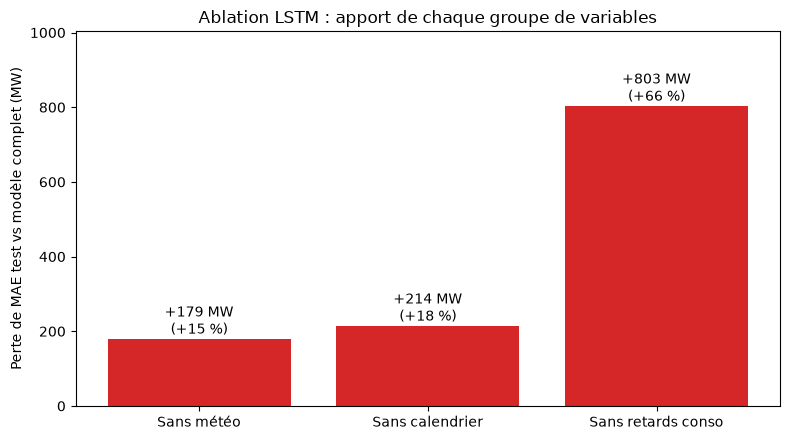

In [29]:
sans = abl.drop(index="Modèle complet")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(sans.index, sans["Δ MAE test vs complet"], color="tab:red")
for i, (v, p) in enumerate(zip(sans["Δ MAE test vs complet"], sans["Δ %"])):
    ax.text(i, v + 15, f"+{v:.0f} MW\n(+{p:.0f} %)", ha="center")

ax.set_ylim(0, sans["Δ MAE test vs complet"].max() * 1.25)   # laisse la place aux étiquettes
ax.set_ylabel("Perte de MAE test vs modèle complet (MW)")
ax.set_title("Ablation LSTM : apport de chaque groupe de variables")
plt.tight_layout(); plt.show()

 Les trois groupes sont utiles, et le classement est identique en validation et en test.

- **Les retards de consommation sont de loin les plus importants** : sans eux, l'erreur augmente de 66 %. Ils donnent au modèle le niveau de charge du moment (consommation des 7 derniers jours, jour J-6 et veille du jour cible) ; sans ce point d'ancrage, la prévision doit se reconstruire uniquement à partir de la météo et du calendrier.
- **Le calendrier** apporte +17,5 % : jour de la semaine, jours fériés, vacances et saisonnalité structurent la demande, mais une partie de cette information est déjà présente de façon implicite dans l'historique de consommation, qui reflète les cycles hebdomadaires et journaliers.
- **La météo** apporte +14,7 %, un effet plus modeste que prévu, qui s'explique par deux limites : elle n'est disponible que sous forme d'observations persistées à 14 h (pas de prévision de J+1), et l'historique de consommation contient déjà une trace de l'effet de la température (chauffage).

**Comparaison avec XGBoost.** Le même ordre se retrouve avec XGBoost (retards +72 %, calendrier +53 %, météo +27 %), avec des écarts plus marqués. L'effet moins fort du calendrier et de la météo sur le LSTM s'explique par sa fenêtre de 7 jours d'historique, qui encode implicitement une partie de ces informations ; XGBoost, qui travaille sur des variables ponctuelles, en dépend davantage.

**Limites.** Les groupes sont corrélés : les écarts mesurent l'apport marginal de chaque groupe et ne s'additionnent pas. Les ensembles de 3 réseaux donnent une MAE test de 1 217 MW pour le modèle complet, légèrement supérieure aux 1 166 MW de l'ensemble final à 5 réseaux (un ensemble plus grand réduit la variance).

## 7. Sauvegarde

In [30]:
dossier = PROCESSED_DIR / "lstm"
dossier.mkdir(parents=True, exist_ok=True)
torch.save({"etats": [m.state_dict() for m in modeles], "config": CONFIG},
           dossier / "lstm_ensemble.pt")
json.dump(scalers, open(dossier / "scalers.json", "w"))
print("Sauvegardé dans", dossier)

Sauvegardé dans C:\Users\bahri\Desktop\temporal data analysis\ConsommationElectrique\data\processed\lstm
